In [2]:
!pip install openmeteo-requests requests-cache retry-requests pandas numpy tensorflow scikit-learn

In [ ]:
import openmeteo_requests, requests_cache, pandas as pd, numpy as np
from retry_requests import retry
# Настройка подключения
openmeteo = openmeteo_requests.Client(session = retry(requests_cache.CachedSession('.cache', expire_after=-1), retries=5))
def get_data(lat, lon):
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": "2018-01-01", "end_date": "2024-01-01",
        "hourly": ["temperature_2m", "relative_humidity_2m", "pressure_msl", "precipitation", "wind_speed_10m"],
        "wind_speed_unit": "ms"
    }
    res = openmeteo.weather_api("https://archive-api.open-meteo.com/v1/archive", params=params)[0].Hourly()
    return pd.DataFrame({
        "t_air": res.Variables(0).ValuesAsNumpy(),
        "h_air": res.Variables(1).ValuesAsNumpy(),
        "press": res.Variables(2).ValuesAsNumpy(),
        "rain": res.Variables(3).ValuesAsNumpy(),
        "wind": res.Variables(4).ValuesAsNumpy()
    })
df_raw = pd.concat([get_data(50.28, 57.17), get_data(25.76, -80.19), get_data(-6.20, 106.84)])
# 11 входов
df = pd.DataFrame()
df['t_air'], df['h_air'], df['press'], df['wind'] = df_raw['t_air'], df_raw['h_air'], df_raw['press'], df_raw['wind']
df['rain'] = df_raw['rain'] * 100
df['soil_t'] = df['rain'].rolling(6).mean().fillna(0) * 5
df['soil_m'] = df['rain'].rolling(24).mean().fillna(0) * 8
df['soil_b'] = df['rain'].rolling(168).mean().fillna(0) * 12
df['t_water'] = df['t_air'].rolling(24).mean().fillna(20) - 2
df['gas'] = 150 + (df['h_air'] * 0.4)
df['vib'] = np.where(df['wind'] > 16, np.random.uniform(3, 5, len(df)), np.random.uniform(0, 0.2, len(df)))
destructive = df[(df['rain'] > 50) | (df['wind'] > 17) | (df['vib'] > 2)]
normal = df.drop(destructive.index).sample(n=len(destructive)*4)
df_final = pd.concat([destructive, normal]).sample(frac=1).reset_index(drop=True).dropna()
df_final.to_csv('real_data.csv', index=False)
print(f"Готово {len(df_final)}")

Качаю
Готово 48910


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae', tf.keras.metrics.RootMeanSquaredError()])
# 3. Обучение
history = model.fit(
    X, y,
    epochs=100,
    batch_size=128, 
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
# Сохранение весов
model.save('next_antique_brain_v2.h5')

старт
Epoch 1/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0019 - mae: 0.0264 - root_mean_squared_error: 0.0440 - val_loss: 0.0019 - val_mae: 0.0290 - val_root_mean_squared_error: 0.0432
Epoch 2/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0019 - mae: 0.0260 - root_mean_squared_error: 0.0435 - val_loss: 0.0018 - val_mae: 0.0268 - val_root_mean_squared_error: 0.0425
Epoch 3/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0019 - mae: 0.0259 - root_mean_squared_error: 0.0434 - val_loss: 0.0018 - val_mae: 0.0258 - val_root_mean_squared_error: 0.0425
Epoch 4/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0019 - mae: 0.0258 - root_mean_squared_error: 0.0433 - val_loss: 0.0018 - val_mae: 0.0251 - val_root_mean_squared_error: 0.0422
Epoch 5/100
306/306 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0019 - mae: 0.0258 - root_mean_squared_error: 0.0432 - val_loss: 0.0018 - val_mae: 0.0259 - val_root_mean_squared_error: 0.0425
Epoch 6/100
306/306 ━━━━━━━━━━━━━━━━

бытты


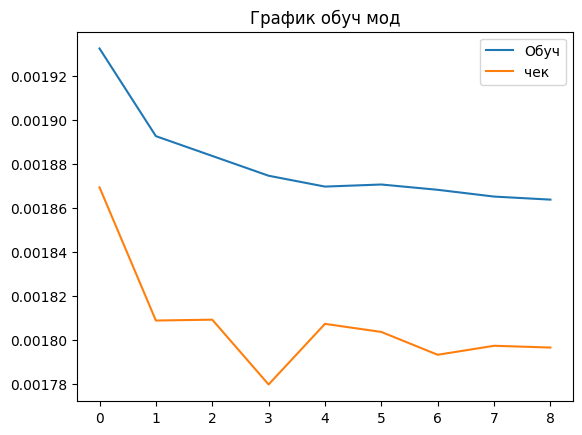

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Обучения')
plt.plot(history.history['val_loss'], label='провеврка')
plt.title('График обучения моделя под низкой разницы')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


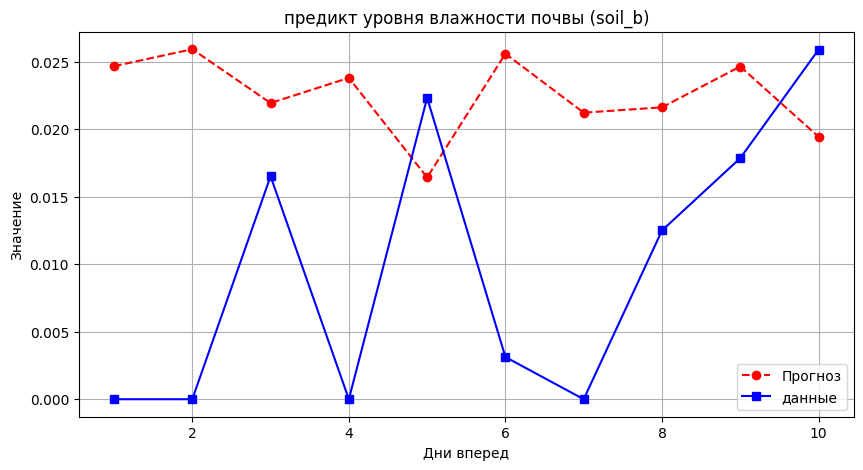

In [ ]:
import matplotlib.pyplot as plt
test_sample = X[np.random.randint(0, len(X))].reshape(1, 15, 11)
real_future = y[np.random.randint(0, len(y))]

prediction = model.predict(test_sample)[0]

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), prediction, 'ro--', label='Прогноз')
plt.plot(range(1, 11), real_future, 'bs-', label='данные')
plt.title('предикт уровня влажности почвы (soil_b)')
plt.xlabel('Дни вперед')
plt.ylabel('Значение')
plt.legend()
plt.grid()
plt.show()